In [9]:
import pandas as pd
import numpy as np
import pyodbc
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import GridSearchCV
 
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


In [10]:
SERVER_NAME   = 'Z14-55M\SQLEXPRESS'     
DATABASE_NAME = 'ChurnPrediction'         
TABLE_NAME    = 'CustomerChurn'  # cleaned table saved in SSMS
conn = pyodbc.connect(
    f'DRIVER={'SQL Server'};'
    f'SERVER={SERVER_NAME};'
    f'DATABASE={DATABASE_NAME};'
    f'Trusted_Connection=yes;'
)
df = pd.read_sql(f'SELECT * FROM {TABLE_NAME}', conn)
conn.close()
 
print('Shape:', df.shape)
print('Nulls:', df.isnull().sum().sum())  # should be 0
df.head(7043)


Shape: (7043, 21)
Nulls: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0002-ORFBO,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.599998,593.299988,No
1,0003-MKNFE,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.900002,542.400024,No
2,0004-TLHLJ,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.900002,280.850006,Yes
3,0011-IGKFF,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.000000,1237.849976,Yes
4,0013-EXCHZ,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.900002,267.399994,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,Female,0,No,No,13,Yes,No,DSL,Yes,...,No,Yes,No,No,One year,No,Mailed check,55.150002,742.900024,No
7039,9992-RRAMN,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.099998,1873.699951,Yes
7040,9992-UJOEL,Male,0,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.299999,92.750000,No
7041,9993-LHIEB,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.849998,4627.649902,No


In [11]:
# Ensure TotalCharges is numeric (SQL may return as string)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Encode target: Yes -> 1, No -> 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print('Churn distribution:')
print(df['Churn'].value_counts())
print(f"Churn rate: {df['Churn'].mean()*100:.1f}%")

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 26.5%


In [12]:
# Feature 1: Tenure Group (matches SQL tenure segmentation)
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 36, 72],
    labels=['New', 'Mid', 'Loyal']
)
# Feature 2: Service Count
service_cols = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]
df['ServiceCount'] = df[service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)
# Feature 3: High Spender flag
df['HighSpender'] = (df['MonthlyCharges'] > 70).astype(int)
# Feature 4: Contract Risk (matches SQL churn by contract type)
df['ContractRisk'] = (df['Contract'] == 'Month-to-month').astype(int)
# Feature 5: Average Monthly Spend
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
print('Features created:')
df[['TenureGroup','ServiceCount','HighSpender','ContractRisk','AvgMonthlySpend']].head(3)
df.head(7043)

Features created:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,ServiceCount,HighSpender,ContractRisk,AvgMonthlySpend
0,0002-ORFBO,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,Yes,Mailed check,65.599998,593.299988,0,New,4,0,0,59.329999
1,0003-MKNFE,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,Mailed check,59.900002,542.400024,0,New,3,0,1,54.240002
2,0004-TLHLJ,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,Electronic check,73.900002,280.850006,1,New,2,1,1,56.170001
3,0011-IGKFF,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,Electronic check,98.000000,1237.849976,1,Mid,5,1,1,88.417855
4,0013-EXCHZ,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,Yes,Mailed check,83.900002,267.399994,1,New,3,1,1,66.849998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,Female,0,No,No,13,Yes,No,DSL,Yes,...,No,Mailed check,55.150002,742.900024,0,Mid,3,0,0,53.064287
7039,9992-RRAMN,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,...,Yes,Electronic check,85.099998,1873.699951,1,Mid,3,1,1,81.465215
7040,9992-UJOEL,Male,0,No,No,2,Yes,No,DSL,No,...,Yes,Mailed check,50.299999,92.750000,0,New,2,0,1,30.916667
7041,9993-LHIEB,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,...,No,Mailed check,67.849998,4627.649902,0,Loyal,5,0,0,68.053675


In [13]:
# TenureGroup: ordinal encode (preserves meaningful order)
tenure_map = {'New': 0, 'Mid': 1, 'Loyal': 2}
df['TenureGroup'] = df['TenureGroup'].astype(str).map(tenure_map)
 
# All other string columns: label encode
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'customerID']
 
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
 
print('Encoding done. Data types:')
print(df.dtypes.value_counts())
df.head(7043)

Encoding done. Data types:
int64      21
float64     4
object      1
Name: count, dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,ServiceCount,HighSpender,ContractRisk,AvgMonthlySpend
0,0002-ORFBO,0,0,1,1,9,1,0,0,0,...,1,3,65.599998,593.299988,0,0.0,4,0,0,59.329999
1,0003-MKNFE,1,0,0,0,9,1,2,0,0,...,0,3,59.900002,542.400024,0,0.0,3,0,1,54.240002
2,0004-TLHLJ,1,0,0,0,4,1,0,1,0,...,1,2,73.900002,280.850006,1,0.0,2,1,1,56.170001
3,0011-IGKFF,1,1,1,0,13,1,0,1,0,...,1,2,98.000000,1237.849976,1,1.0,5,1,1,88.417855
4,0013-EXCHZ,0,1,1,0,3,1,0,1,0,...,1,3,83.900002,267.399994,1,0.0,3,1,1,66.849998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,0,0,0,0,13,1,0,0,2,...,0,3,55.150002,742.900024,0,1.0,3,0,0,53.064287
7039,9992-RRAMN,1,0,1,0,22,1,2,1,0,...,1,2,85.099998,1873.699951,1,1.0,3,1,1,81.465215
7040,9992-UJOEL,1,0,0,0,2,1,0,0,0,...,1,3,50.299999,92.750000,0,0.0,2,0,1,30.916667
7041,9993-LHIEB,1,0,1,1,67,1,0,0,2,...,0,3,67.849998,4627.649902,0,2.0,5,0,0,68.053675


In [14]:
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']
 
# 80/20 split, stratified to keep churn ratio balanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
 
print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')
print(f'Churn % train: {y_train.mean()*100:.1f}% | test: {y_test.mean()*100:.1f}%')

Train: 5634 rows | Test: 1409 rows
Churn % train: 26.5% | test: 26.5%


In [15]:
rf = RandomForestClassifier(
    n_estimators=100,        # 100 decision trees
    class_weight='balanced', # handles churn imbalance (~26%)
    random_state=42,
    n_jobs=-1                # use all CPU cores
)
rf.fit(X_train_s, y_train)
print('Random Forest training complete.')

Random Forest training complete.


In [16]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges         0
Churn                0
TenureGroup         11
ServiceCount         0
HighSpender          0
ContractRisk         0
AvgMonthlySpend      0
dtype: int64

In [17]:
y_pred  = rf.predict(X_test_s)
y_proba = rf.predict_proba(X_test_s)[:, 1]  # churn probability
auc = roc_auc_score(y_test, y_proba)
print('=' * 50)
print(f'ROC-AUC Score: {auc:.4f}')
print('=' * 50)
print('\nClassification Report:')
print(classification_report(y_test, y_pred,
      target_names=['No Churn', 'Churn']))

ROC-AUC Score: 0.8216

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.82      0.90      0.86      1035
       Churn       0.64      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



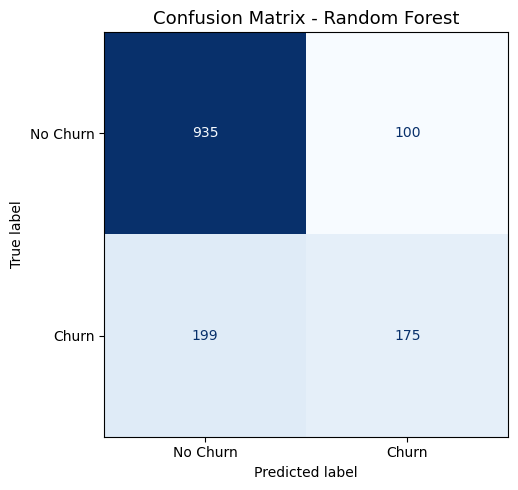

Saved: confusion_matrix.png


In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix - Random Forest', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Saved: confusion_matrix.png')

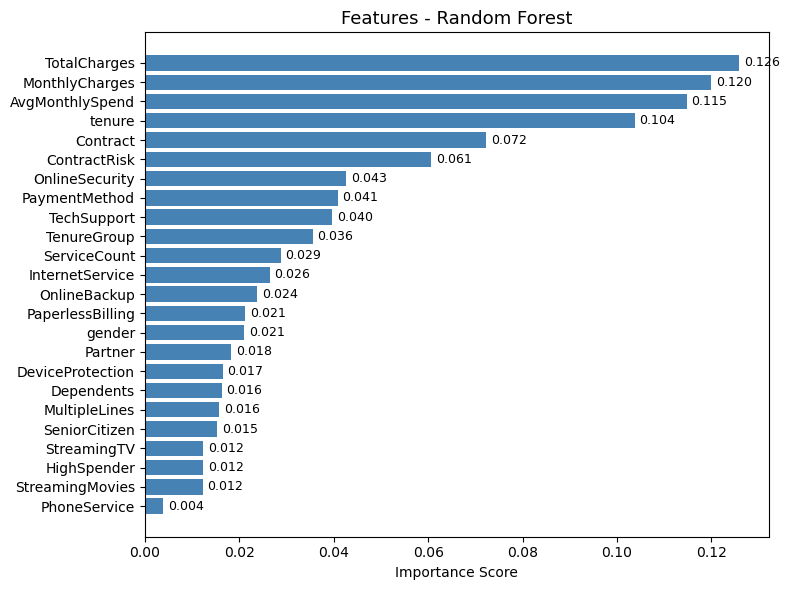

Saved: feature_importance.png


In [19]:
feat_imp = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(26)
 
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(feat_imp['Feature'][::-1],
               feat_imp['Importance'][::-1], color='steelblue')
ax.set_xlabel('Importance Score')
ax.set_title('Features - Random Forest', fontsize=13)
for bar, val in zip(bars, feat_imp['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print('Saved: feature_importance.png')

In [20]:
# Define parameter grid to search
param_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2]
}
# GridSearchCV with 5-fold cross validation
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_s, y_train)
print('Best Parameters:', grid_search.best_params_)
print('Best ROC-AUC (CV):', round(grid_search.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best ROC-AUC (CV): 0.8434


In [21]:
# Use the best model found by GridSearchCV
best_rf = grid_search.best_estimator_
y_pred_tuned  = best_rf.predict(X_test_s)
y_proba_tuned = best_rf.predict_proba(X_test_s)[:, 1]
auc_tuned = roc_auc_score(y_test, y_proba_tuned)
print('=' * 50)
print(f'Tuned Model ROC-AUC: {auc_tuned:.4f}')
print('=' * 50)
print(classification_report(y_pred_tuned, y_test,
      target_names=['No Churn', 'Churn']))

Tuned Model ROC-AUC: 0.8447
              precision    recall  f1-score   support

    No Churn       0.79      0.89      0.84       925
       Churn       0.72      0.56      0.63       484

    accuracy                           0.77      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.77      0.77      0.76      1409



In [22]:
final_model  = best_rf if 'best_rf' in dir() else rf
final_pred   = final_model.predict(X_test_s)
final_proba  = final_model.predict_proba(X_test_s)[:, 1]
 
predictions_df = pd.DataFrame({
    'customerID':        df['customerID'].iloc[X_test.index].values,
    'Actual_Churn':      y_test.values,
    'Predicted_Churn':   final_pred,
    'Churn_Probability': final_proba.round(4)
})
 
# Risk tier column for Power BI slicer/filter
predictions_df['Risk_Tier'] = pd.cut(
    predictions_df['Churn_Probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)
predictions_df.to_csv('predictions_output.csv', index=False)
print('Saved: predictions_output.csv')
print(f'Total customers: {len(predictions_df)}')
print(f'High Risk customers: {(predictions_df["Risk_Tier"]=="High Risk").sum()}')
predictions_df.head()

Saved: predictions_output.csv
Total customers: 1409
High Risk customers: 374


,customerID,Actual_Churn,Predicted_Churn,Churn_Probability,Risk_Tier
0,0668-OGMHD,0,0,0.3550,Medium Risk
1,3292-PBZEJ,0,1,0.7845,High Risk
2,3223-DWFIO,0,1,0.6920,High Risk
3,6377-KSLXC,0,0,0.2461,Low Risk
4,5360-XGYAZ,0,0,0.0094,Low Risk


In [23]:
feat_imp_full = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)
 
feat_imp_full.to_csv('feature_importance.csv', index=False)
print('Saved: feature_importance.csv')
print(feat_imp_full.head(10))

Saved: feature_importance.csv
            Feature  Importance
14         Contract    0.118064
4            tenure    0.103613
22     ContractRisk    0.101649
18     TotalCharges    0.094185
17   MonthlyCharges    0.084338
23  AvgMonthlySpend    0.080298
11      TechSupport    0.061504
8    OnlineSecurity    0.060156
19      TenureGroup    0.048584
7   InternetService    0.038853


In [25]:
import joblib
# Save column names in order
model_features = list(X_train.columns)
joblib.dump(model_features, 'model_features.pkl')
# Save Random Forest model 
joblib.dump(final_model, 'churn_model.pkl')
print("Successfully saved model and columns! Total features expected:", len(model_features))

Successfully saved model and columns! Total features expected: 24
